# Ollama

In [ ]:
! apt-get install pciutils pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  libpci3 pci.ids
The following NEW packages will be installed:
  libpci3 pci.ids pciutils
0 upgraded, 3 newly installed, 0 to remove and 41 not upgraded.
Need to get 343 kB of archives.
After this operation, 1,581 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 pci.ids all 0.0~2022.01.22-1ubuntu0.1 [251 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpci3 amd64 1:3.7.0-6 [28.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 pciutils amd64 1:3.7.0-6 [63.6 kB]
Fetched 343 kB in 1s (321 kB/s)
Selecting previously unselected package pci.ids.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../pci.ids_0.0~2022.01.22-1ubuntu0.

In [ ]:
! lspci

00:00.0 Host bridge: Intel Corporation 440FX - 82441FX PMC [Natoma] (rev 02)
00:01.0 ISA bridge: Intel Corporation 82371AB/EB/MB PIIX4 ISA (rev 03)
00:01.3 Bridge: Intel Corporation 82371AB/EB/MB PIIX4 ACPI (rev 03)
00:03.0 Non-VGA unclassified device: Red Hat, Inc. Virtio SCSI
00:04.0 3D controller: NVIDIA Corporation TU104GL [Tesla T4] (rev a1)
00:05.0 Ethernet controller: Red Hat, Inc. Virtio network device
00:06.0 Unclassified device [00ff]: Red Hat, Inc. Virtio RNG


In [ ]:
! curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
# puro gemini pra fazer equivalente a "ollama serve &"

import subprocess, os

# Start Ollama serve in the background using nohup and redirect output to a log file
# This makes it more robust for running in Colab notebooks
subprocess.Popen(['nohup', 'ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, preexec_fn=os.setpgrp)

print("Ollama server started in the background. Check logs for details if needed.")

Ollama server started in the background. Check logs for details if needed.


In [ ]:
! ollama pull llama3

In [ ]:
! ollama list

NAME             ID              SIZE      MODIFIED               
llama3:latest    365c0bd3c000    4.7 GB    Less than a second ago    


In [ ]:
! ps | grep ollama

   2734 ?        00:00:28 ollama


## EasyOCR

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! pip install numpy pdf2image easyocr pypandoc ollama weasyprint -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.1/847.1 kB 54.4 MB/s eta 0:00:00


In [ ]:
import os
import easyocr
import pypandoc
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

In [ ]:
def preprocess_basic(img):
  if len(img.shape) == 3:
      img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

  # Denoise
  denoised = cv.fastNlMeansDenoising(img, None, 10, 7, 21)

  # CLAHE
  clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

  enhanced = clahe.apply(denoised)

  return enhanced

In [ ]:
def sharpen(img):
  kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
  ])

  sharpened = cv.filter2D(img, -1, kernel)

  return sharpened

In [ ]:
def preprocess_pipeline(img):
  print('\nantes:')
  cv2_imshow(img)

  #img = preprocess_basic(img)
  img = sharpen(img)

  print('\ndepois:')
  cv2_imshow(img)
  return img

In [ ]:
def get_prob(img):
  reader = easyocr.Reader(["pt"])

  output = []

  result = reader.readtext(img)
  output.append(result)

  return output

In [ ]:
def ocr_output(output):
  for page_output in output:
    print('='*6)
    print(f'Output')
    print('='*6)
    for (bbox, word, prob) in page_output:
      print(f'{word} [Probabilidade: {prob:.3f}]')

## IA & PDF

In [ ]:
def get_text(img):
  reader = easyocr.Reader(["pt"])

  output = []

  result = reader.readtext(img, detail = 0)
  output.append(result)

  return output

In [ ]:
def save_pdf(text, file):

    dir_path = os.path.dirname(file)
    pdf_path = os.path.join(dir_path, f"relatorio.pdf")

    pypandoc.convert_text(
        text,
        "pdf",
        format="md",
        outputfile=pdf_path,
        extra_args=["--standalone", "--pdf-engine=weasyprint"],
    )

In [ ]:
from ollama import chat
from ollama import ChatResponse


def anamnese_ai_analysis(ocr_text):
    response: ChatResponse = chat(
        model="llama3",
        messages=[
            {
                "role": "user",
                "content": "Interprete os seguintes dados do paciente e gere um relatório simples com achados, possíveis diagnósticos e sugestões finais em Português do Brasil (PTBR), dividido em Títulos, subtítulos e seções em formato MARKDOWN. "
                + str(ocr_text),
            },
        ],
    )
    return response.message.content

## Main

In [ ]:
def mostrar_img(img_name):
  DRIVE_FOLDER_PATH = '/content/drive/MyDrive/ocr_anamnese'

  img_name = os.path.join(DRIVE_FOLDER_PATH, img_name)

  img_data = cv.imread(img_name)

  if img_data is not None:
      print('raw:')
      cv2_imshow(img_data)
  else:
      print(f"Error: Could not load image from {img_name}")
  return img_data, img_name

In [ ]:
def main(img_data, img_name):
  out_antes = get_prob(img_data)
  ocr_output(out_antes)
  prep = preprocess_pipeline(img_data)

  out = get_prob(prep)
  ocr_output(out)

  #ia e pdf
  out_for_pdf = get_text(prep)

  result = anamnese_ai_analysis(out_for_pdf)
  save_pdf(result, img_name)

raw:


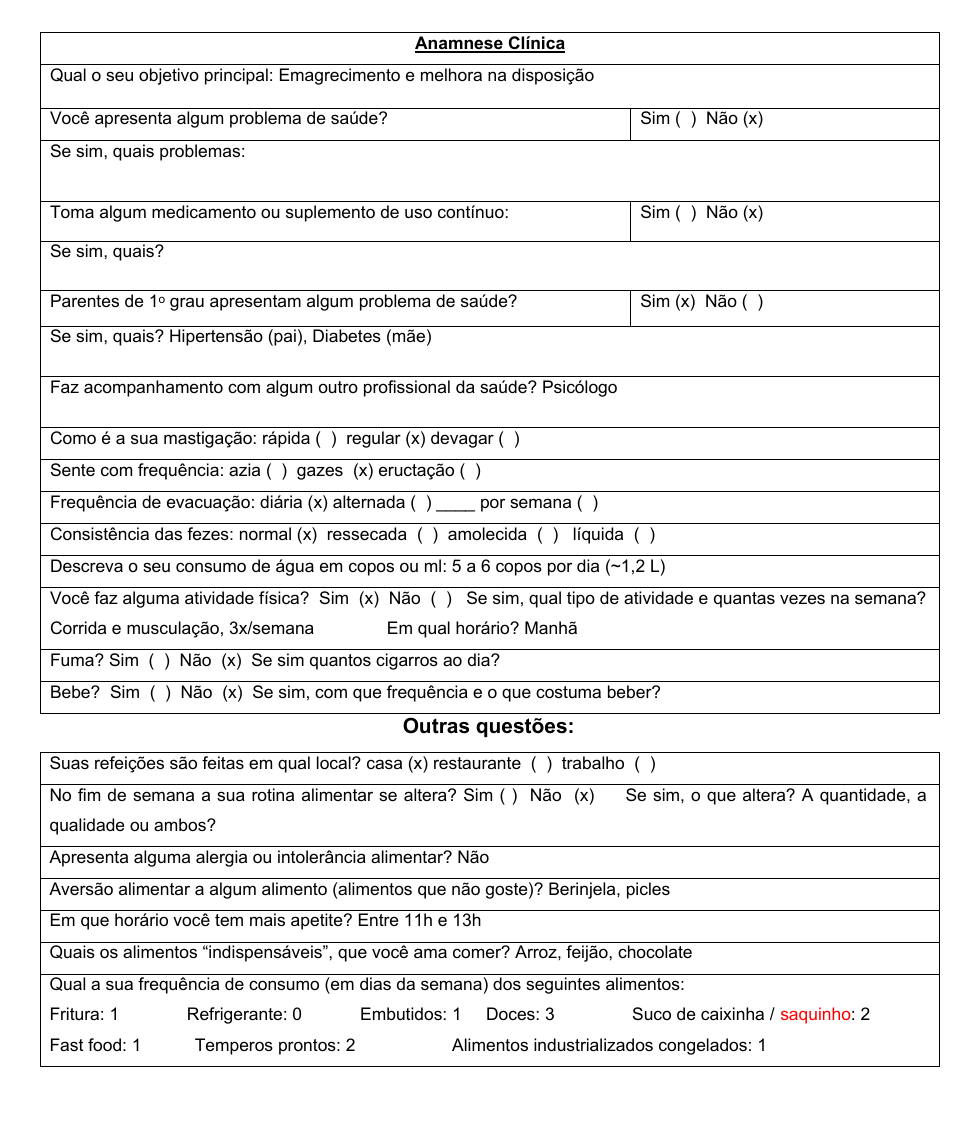

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete======
Output
Anamnese Clinica [Probabilidade: 0.719]
Qual 0 seu objetivo principal: Emagrecimento e melhora na disposição [Probabilidade: 0.765]
Você apresenta algum problema de saúde? [Probabilidade: 0.877]
Sim [Probabilidade: 0.999]
Não (x) [Probabilidade: 0.927]
Se sim; quais problemas: [Probabilidade: 0.696]
Toma algum medicamento ou suplemento de uso contínuo: [Probabilidade: 0.847]
Sim [Probabilidade: 0.995]
Não [Probabilidade: 1.000]
Se sim; [Probabilidade: 0.653]
quais? [Probabilidade: 1.000]
Parentes de 1ª grau apresentam algum problema de saúde? [Probabilidade: 0.908]
Sim [Probabilidade: 1.000]
Não ( ) [Probabilidade: 0.958]
Se sim, quais? Hipertensão (pai) Diabetes (mãe) [Probabilidade: 0.810]
Faz acompanhamento com algum outro profissional da saúde? Psicólogo [Probabilidade: 0.654]
Como é a sua mastigação: rápida [Probabilidade: 0.611]
regular [Probabilidade: 1.000]
devagar [Probabilidade: 1.000]

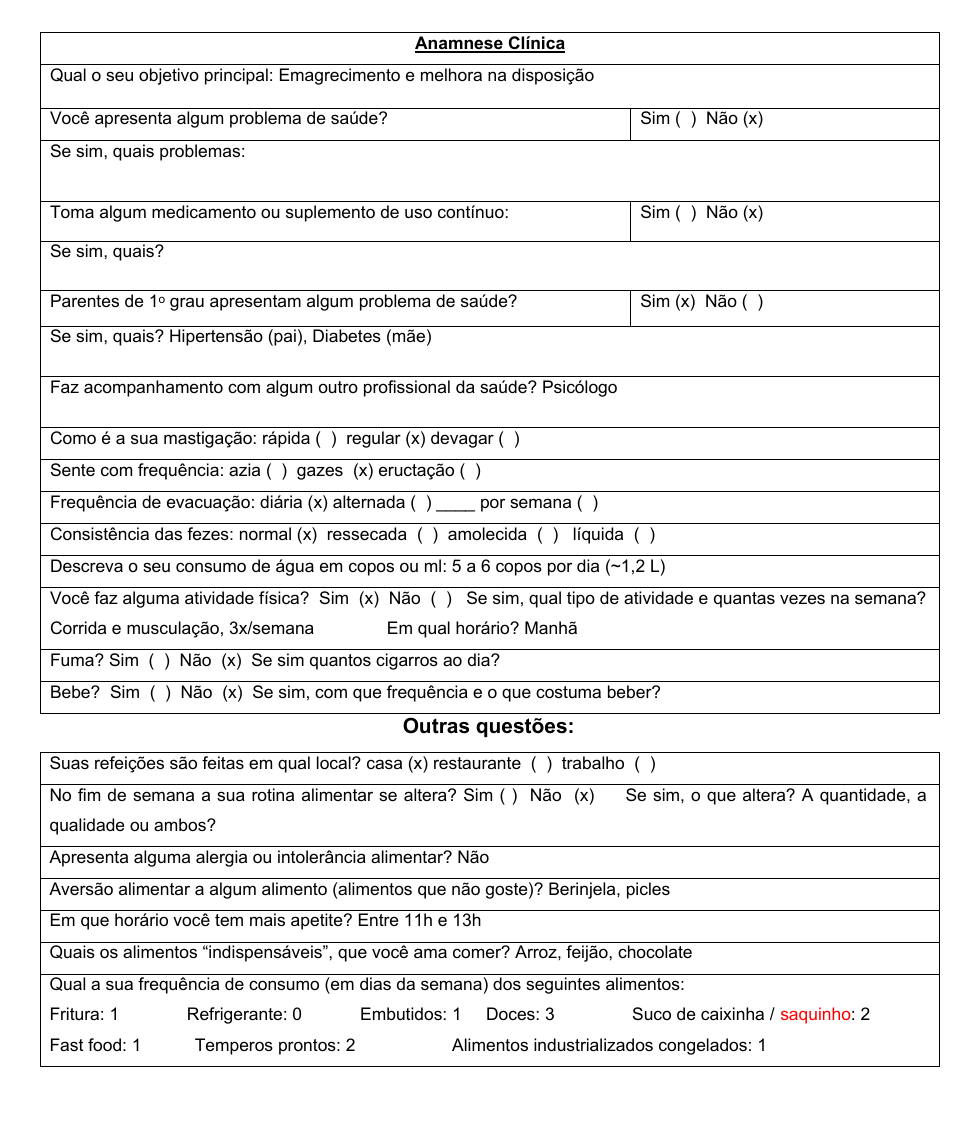


depois:


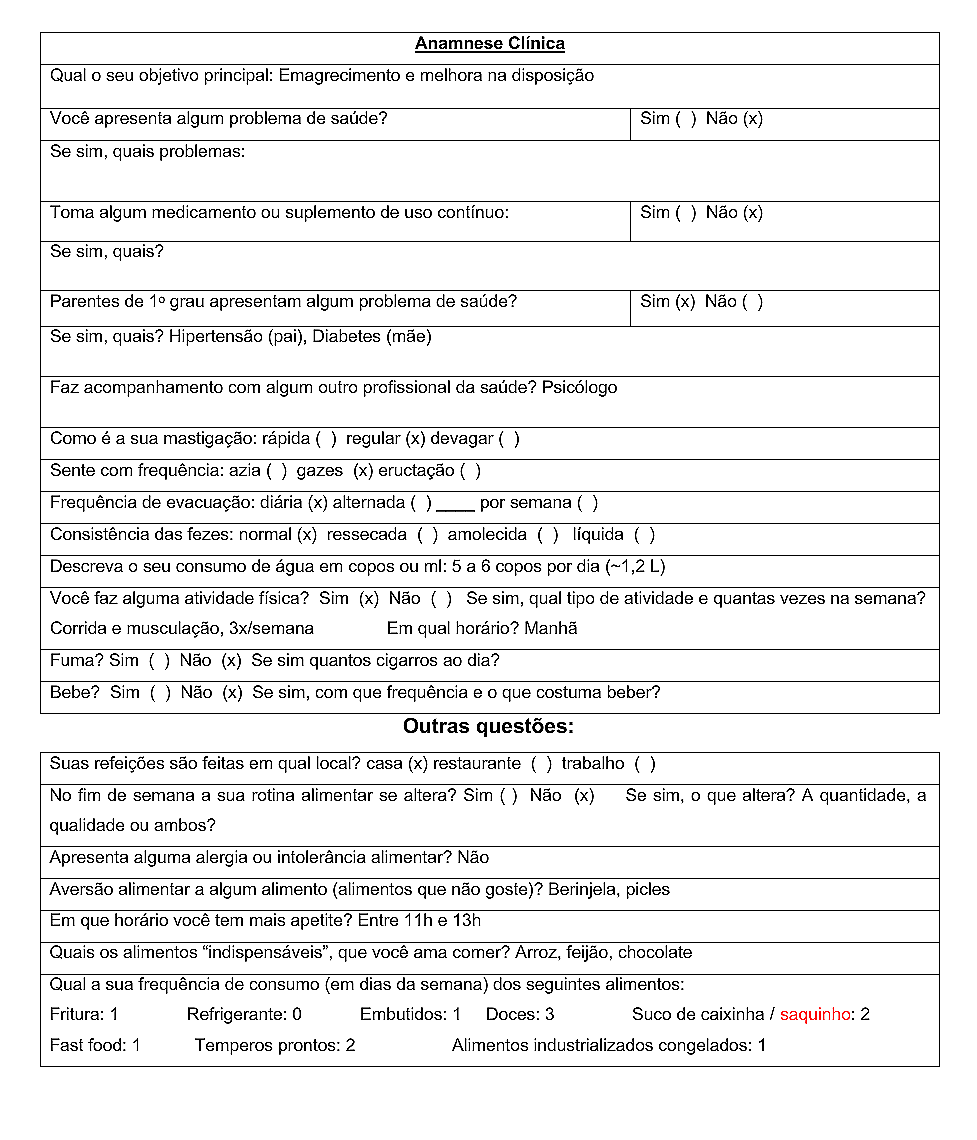

Output
Anamnese [Probabilidade: 0.998]
Chiica [Probabilidade: 0.305]
Qual 0 seu objetivo principal: Emagrecimento e melhora na disposição [Probabilidade: 0.762]
Você apresenta algum problema de saúde? [Probabilidade: 0.932]
Sim [Probabilidade: 0.999]
Não (x) [Probabilidade: 0.990]
Se sim, quais problemas: [Probabilidade: 0.779]
Toma algum medicamento ou suplemento de uso contínuo: [Probabilidade: 0.750]
Sim [Probabilidade: 0.971]
Não [Probabilidade: 1.000]
Se sim [Probabilidade: 0.778]
quais? [Probabilidade: 1.000]
Parentes de [Probabilidade: 0.866]
grau apresentam algum problema de saúde? [Probabilidade: 0.917]
Sim (x) Não () [Probabilidade: 0.260]
Se [Probabilidade: 0.999]
quais? Hipertensão (pai) Diabetes (mãe) [Probabilidade: 0.802]
Faz acompanhamento com algum outro profissional da saúde? Psicólogo [Probabilidade: 0.706]
Como é a sua [Probabilidade: 0.860]
mastigação: rápida [Probabilidade: 0.957]
regular (x) devagar [Probabilidade: 0.982]
Sente com frequência: azia [Probabilidade

[WARNING] This document format requires a nonempty <title> element.
  Defaulting to '-' as the title.
  To specify a title, use 'title' in metadata or --metadata title="...".

  Defaulting to '-' as the title.
  To specify a title, use 'title' in metadata or --metadata title="...".



In [ ]:
if __name__ == '__main__':
  img_data, img_name = mostrar_img('anamnese_pag2.png')
  main(img_data, img_name)